In [ ]:
# numpy: sayısal hesaplamalar — matris çarpımı, tanh, exp vb.
# Sıfırdan LSTM'yi numpy ile yazacağız: PyTorch'un içinde ne olduğunu görmek için.
import numpy as np

# torch: derin öğrenme — otomatik türev (autograd) + GPU desteği
import torch

# torch.nn: hazır katmanlar — nn.LSTM, nn.Linear, nn.Dropout
import torch.nn as nn

# torch.optim: optimizörler — Adam, SGD, RMSProp
# Ağırlıkları güncellemek için kullanılır.
import torch.optim as optim

# matplotlib: grafik çizimi
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Tekrarlanabilirlik: sabit tohum → her çalışmada aynı sonuç
np.random.seed(42)
torch.manual_seed(42)

print("✓ NumPy  :", np.__version__)
print("✓ PyTorch:", torch.__version__)
print()
print("numpy   → sıfırdan LSTM için matematiksel işlemler")
print("torch   → PyTorch modeli, eğitim ve GPU desteği")
print("matplotlib → tüm grafikler")


✓ NumPy  : 2.0.2
✓ PyTorch: 2.11.0+cpu

numpy   → sıfırdan LSTM için matematiksel işlemler
torch   → PyTorch modeli, eğitim ve GPU desteği
matplotlib → tüm grafikler


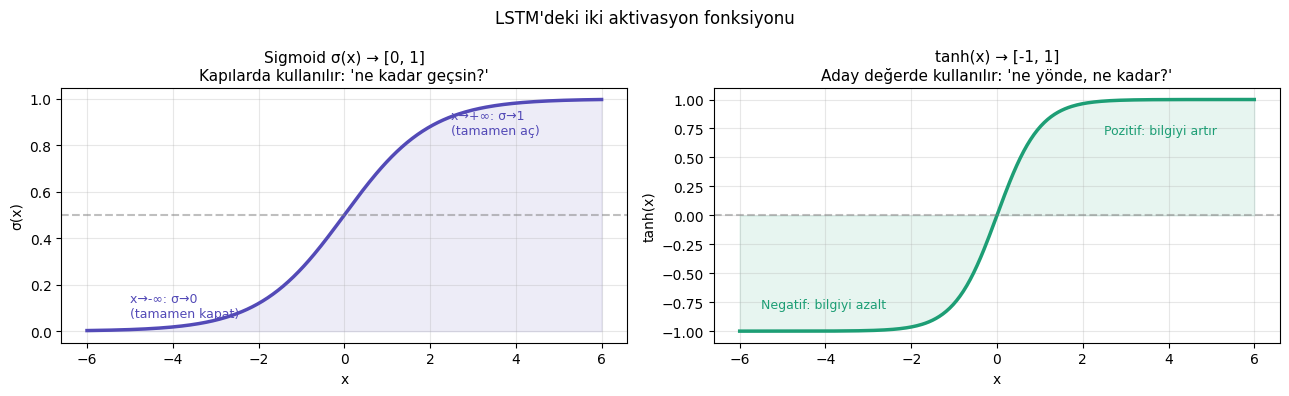

Türev karşılaştırması (gradient akışı açısından kritik):
  sigmoid max türevi : 0.250  (x=0'da)
  tanh    max türevi : 1.000  (x=0'da)

RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır
LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz


In [ ]:
def sigmoid(x):
    """
    σ(x) = 1 / (1 + e^{-x})

    np.clip(x, -500, 500) neden?
    → x=-1000 için e^1000 → sonsuz (overflow).
    → clip ile sınırlandırıyoruz: bu aralıkta sigmoid zaten 0 veya 1'e çok yakın,
      sayısal sonuç değişmez ama hesap kararlı kalır.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


# Grafik
x = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, sigmoid(x), color="#534AB7", linewidth=2.5)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].fill_between(x, sigmoid(x), alpha=0.1, color="#534AB7")
axes[0].set_title("Sigmoid σ(x) → [0, 1]\nKapılarda kullanılır: 'ne kadar geçsin?'", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("σ(x)"); axes[0].grid(alpha=0.3)
axes[0].annotate("x→-∞: σ→0\n(tamamen kapat)", xy=(-5, 0.06), fontsize=9, color="#534AB7")
axes[0].annotate("x→+∞: σ→1\n(tamamen aç)",   xy=(2.5, 0.85), fontsize=9, color="#534AB7")

axes[1].plot(x, np.tanh(x), color="#1D9E75", linewidth=2.5)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].fill_between(x, np.tanh(x), alpha=0.1, color="#1D9E75")
axes[1].set_title("tanh(x) → [-1, 1]\nAday değerde kullanılır: 'ne yönde, ne kadar?'", fontsize=11)
axes[1].set_xlabel("x"); axes[1].set_ylabel("tanh(x)"); axes[1].grid(alpha=0.3)
axes[1].annotate("Negatif: bilgiyi azalt", xy=(-5.5, -0.8), fontsize=9, color="#1D9E75")
axes[1].annotate("Pozitif: bilgiyi artır",  xy=(2.5,  0.7),  fontsize=9, color="#1D9E75")

plt.suptitle("LSTM'deki iki aktivasyon fonksiyonu", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/activations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Türev karşılaştırması (gradient akışı açısından kritik):")
print(f"  sigmoid max türevi : {sigmoid(0)*(1-sigmoid(0)):.3f}  (x=0'da)")
print(f"  tanh    max türevi : {1-np.tanh(0)**2:.3f}  (x=0'da)")
print()
print("RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır")
print("LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz")


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
x = np.array([-5, -2, 0, 2, 5])

print(sigmoid(x))

[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


In [ ]:
x = np.array([-5, -2, 0, 2, 5])

print(np.tanh(x))

[-0.9999092  -0.96402758  0.          0.96402758  0.9999092 ]
